# Ensembling Methods

Ensembling methods are a family of well-established statistical 'add-on' methods to improve the accuracy of predictive models. This is primarily done through bootstrap aggregation (or known as bagging) of the training dataset by creating multiple smaller training subsets. Ensemble SINDy (E-SINDy) as proposed by [(Fasel et al, 2022)](https://royalsocietypublishing.org/rspa/article/478/2260/20210904/56618/Ensemble-SINDy-Robust-sparse-model-discovery-in), further proposes the use of bootstrap robust aggregation (or bragging) as well as library ensembling to further improve robustness and predictive accuracy. In this tutorial, we will cover
1. How data is bootstrapped via bragging.
2. How library ensembling can be carried out.
3. How do the various methods compare and further applications of ensembling.

In [1]:
# Import required libraries

import numpy as np
import pysindy as ps
from scipy import signal
import warnings
from IPython.display import Math, display

from sindy.odes import generate_ode_data, lorenz
from sindy.library import poly_lib
from sindy.optimizer import stridge
from sindy.ensemble import \
    ensemble, subsample_data, subsample_library, benchmark_ensemble, \
    plot_coef_distribution, plot_heatmap, plot_predict_trajectory
from sindy.utils import print_latex_eqn, set_seed
from sindy.plot_utils import init_plt_format, visualize_ode_3d

warnings.filterwarnings('ignore', category=RuntimeWarning)
init_plt_format()
set_seed(0)

# Bootstrapping

The motivation of bootstrapping is to reduce the variance of a given dataset through multiple sampling. However, it is a balancing act between reducing its variance and increasing its bias. As more subsets of smaller datasets increases the bias of the individual models trained by each subset. Let us first generate a Lorenz system with additive Gaussian noise to demonstrate various bootstrapping methods.

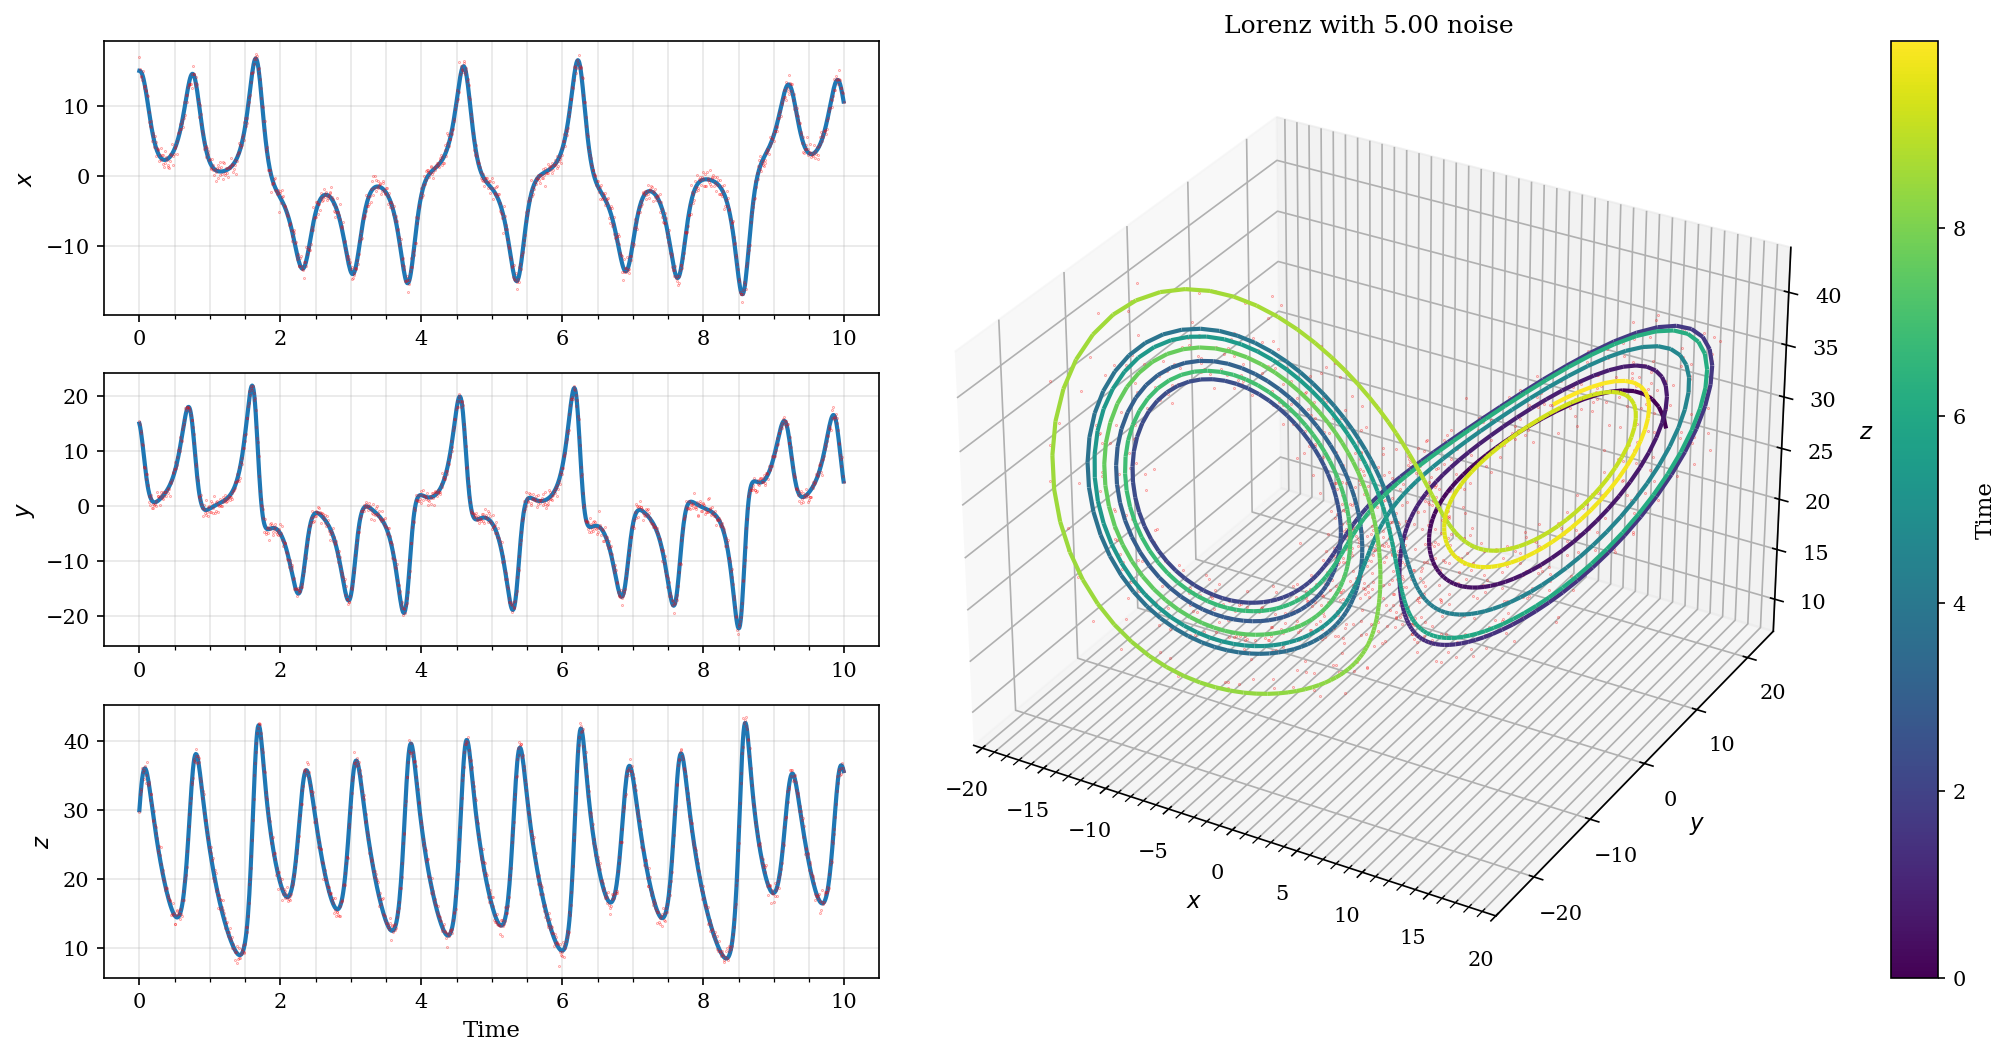

In [2]:
noise_ratios = np.linspace(0, 0.05, 6)

# Define the parameters of the Lorenz ODE
lorenz_params: list = [10, 8/3, 28]
state_names: list[str] = ['x', 'y', 'z']

# Generate Lorenz system trajectory
t, x, x_noisy = generate_ode_data(
    1000, 0.01, np.array([15, 15, 30]),
    lorenz, lorenz_params,
    noise_ratios=noise_ratios
)
visualize_ode_3d(
    x, t, x_noisy[-1],
    f"Lorenz with {noise_ratios[-1]*100:.2f} noise"
)

## Bragging

Bragging (bootstrap robust aggregation) involves
1. Creating $B$ subsets of data by sampling $N$ samples with replacement from a dataset of size $N$.
2. Then, a predictive model is fitted for each bootstrapped dataset. 
3. The ensembled model parameters are then computed from the median of all the bagged models.

An implementation of such subsampling is shown below:

In [3]:
subsample_data??

Signature:
subsample_data(
    theta: numpy.ndarray,
    xdot: numpy.ndarray,
    replace: bool,
    n_subset: int,
) -> tuple[numpy.ndarray, numpy.ndarray]
Source:   
def subsample_data(
        theta: np.ndarray, xdot: np.ndarray,
        replace: bool, n_subset: int
) -> tuple[np.ndarray, np.ndarray]:
    """
    This function subsamples data randomly with or with replacement from both
    the candidate function library and the time derivatives.

    Args:
        theta (np.ndarray): Candidate function library matrix.
        xdot (np.ndarray): Time derivative matrix.
        replace (bool): Whether to sample with replacement.
        n_subset (int): Number of samples to include in the subset.

    Returns:
        tuple[np.ndarray, np.ndarray]: Subsampled candidate function library
            and time derivative matrices.
    """
        
    # Get total number of samples
    m: int = theta.shape[0]

    # Check if the number of subset specified is valid
    assert n_subset <= m, 

As the size of the dataset $N$ increases, the probability of not selecting a data sample in a subset converges to $1/e$ as $N \rightarrow \infty$. An example bragging on the Lorenz system identification is as follows:

In [4]:
# Define the noise ratio dataset to use
noise_ratio = 0.01
noise_idx = np.argmin(np.abs(noise_ratios-noise_ratio))

# Define bagging parameter
B: int = 100

# Define SINDy parameters
poly_order: int = 5
include_bias: bool = True
lam: float = 0.2
l2_norm: float = 0.001

# Compute theta and xdot matrices
theta, lib_names = poly_lib(
    x_noisy[noise_idx], poly_order, include_bias, state_names
)
xdot = ps.FiniteDifference(4)._differentiate(x_noisy[noise_idx], t)

# Create a list of models
xis: list[np.ndarray] = list()

for _ in range(B):

    theta_bag, xdot_bag = subsample_data(theta, xdot, True, theta.shape[0])
    xis.append(stridge(theta_bag, xdot_bag, lam, l2_norm))

# Ensemble the final model by computing the median and threshold again
xi: np.ndarray = np.median(np.stack(xis, axis=-1), axis=-1)
xi[np.abs(xi) < lam] = 0.0
display(Math(print_latex_eqn(xi, state_names, lib_names)))

<IPython.core.display.Math object>

As seen from above, bragging by computation of the median parameters is not robust due to sensitivity to outliers. We may also visualise the presence of outliers through the parameter distribution of each coefficient for the first 5 library terms.

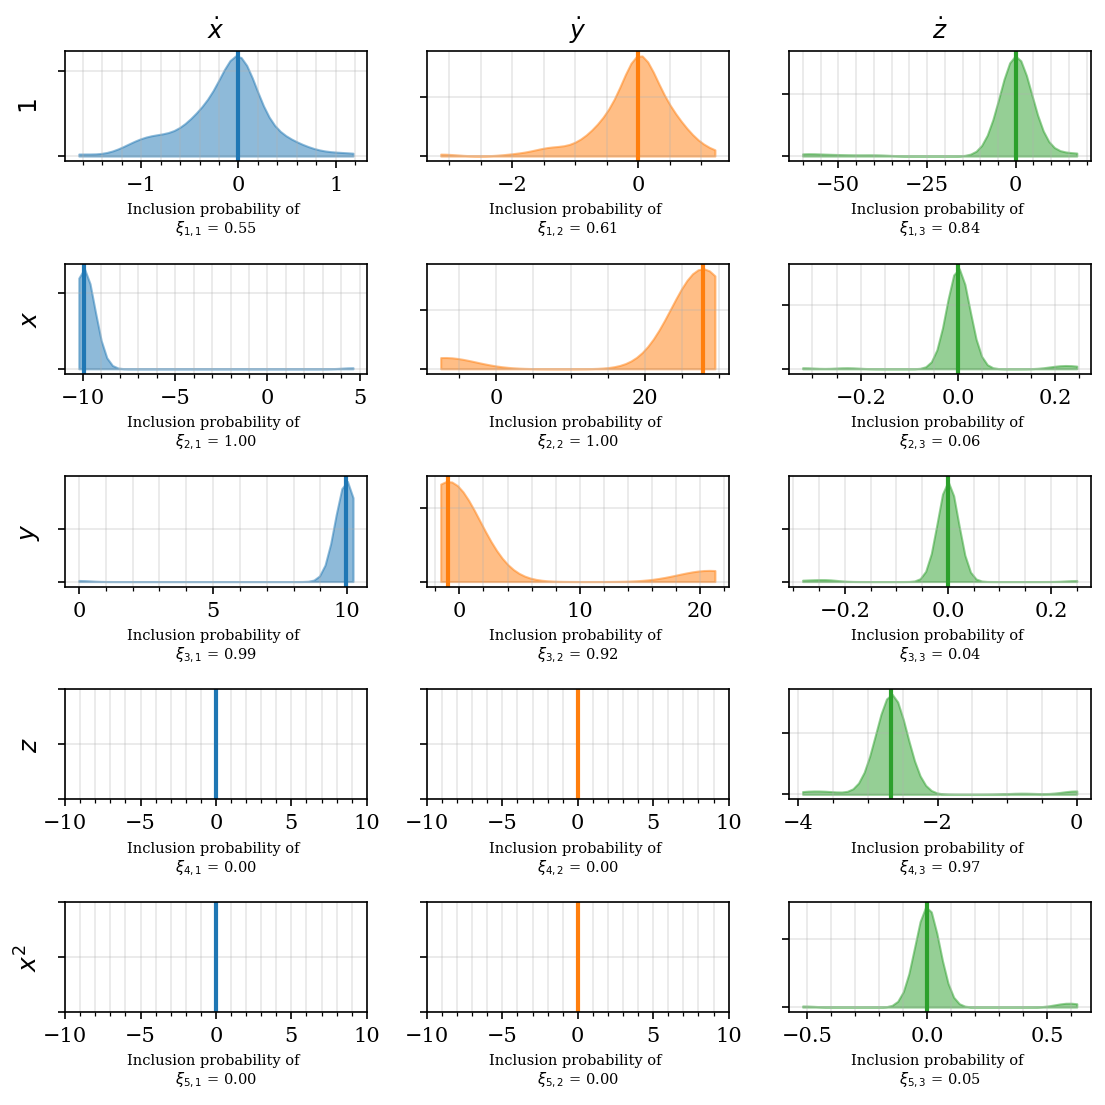

In [5]:
plot_coef_distribution(
    np.stack(xis, axis=-1)[:5],
    state_names, lib_names, useMedian=True
)

## Sub-Bragging

Sub-bragging involves subsampling the $N$ sized datasets where $0 < N < M$ without replacement to perform bragging. [(Buja and Stuetzle, 2006)](http://stat.wharton.upenn.edu/~buja/PAPERS/sinica-bagging-buja-stuetzle.pdf) has shown that under the assumption of unbiased statistics (or U-statistics), sub-bragging with $N = \lfloor M/2 \rfloor$ and without replacement is equivalent to bragging with $N=M$ and with replacement. However, sub-bragging would reduce the total computational requirement by half.

In [6]:
# Create a list of models
xis: list[np.ndarray] = list()

for _ in range(B):

    theta_bag, xdot_bag = subsample_data(
        theta, xdot,
        False, int(np.floor(theta.shape[0]/2))
    )
    xis.append(stridge(theta_bag, xdot_bag, lam, l2_norm))

# Ensemble the final model by computing the mean and threshold again
xi: np.ndarray = np.median(np.stack(xis, axis=-1), axis=-1)
xi[np.abs(xi) < lam] = 0.0
display(Math(print_latex_eqn(xi, state_names, lib_names)))

<IPython.core.display.Math object>

You may find similarities in this procedure to the one used in [stability selection](./1-3%20Model%20Selection.ipynb) for model selection which also employs bootstrapping.

# Library Ensembling

In addition to subsampling our dataset, we may also subsample our library terms. Following the same intuition as [stability selection](./1-3%20Embedding%20Prior%20Knowledge.ipynb), the correct library terms should always be present when possible in a sub-library. We sample our library terms without replacement such that

In [7]:
subsample_library??

Signature: subsample_library(theta: numpy.ndarray, n_candidate_to_drop: int) -> tuple[numpy.ndarray, numpy.ndarray]
Source:   
def subsample_library(
        theta: np.ndarray, n_candidate_to_drop: int
) -> tuple[np.ndarray, np.ndarray]:
    """
    This function subsamples functions from the candidate function library.

    Args:
        theta (np.ndarray): The full candidate function library.
        n_candidate_to_drop (int): Number of candidate functions to drop when
            subsampling.

    Returns:
        tuple[np.ndarray, np.ndarray]: Subsampled candidate function library
            and the corresponding indices of the retained functions.
    """
    
    # Get original library dimension
    l: int = theta.shape[1]
    
    # Validate candidate drop size
    assert n_candidate_to_drop < l, (
        f"Not possible to drop {n_candidate_to_drop:d} from a library with "
        + f"{l:d} candidates!"
    )

    # Drop terms the specified number of candidate terms
    theta_i

An important step to note is that after subsampling, one must index the coefficient matrix $\Xi$ according to the subsample indices to maintain shape consistency. An example implementation is as follows:

In [8]:
# Define the percentage of library terms to drop
lib_drop_ratio: float = 0.1

# Compute theta and xdot matrices
theta, lib_names = poly_lib(
    x_noisy[noise_idx], poly_order, include_bias, state_names
)
xdot = ps.FiniteDifference(4)._differentiate(x_noisy[noise_idx], t)

# Define data dimensions
l: int = theta.shape[1]
n: int = xdot.shape[1]

# Create a list of models
xis: list[np.ndarray] = list()

for _ in range(B):

    # Subsample library
    theta_bag, theta_idx = subsample_library(
        theta, int(lib_drop_ratio*l)
    )

    # Initialise xi matrix as its original size and use the subsampling indices
    # to maintain shape consistency
    xi: np.ndarray = np.zeros((l, n))
    xi[theta_idx, :] = stridge(theta_bag, xdot, lam, l2_norm)
    xis.append(xi)

# Ensemble the final model by computing the mean and threshold again
xi: np.ndarray = np.median(np.stack(xis, axis=-1), axis=-1)
xi[np.abs(xi) < lam] = 0.0
display(Math(print_latex_eqn(xi, state_names, lib_names)))

<IPython.core.display.Math object>

Let us now visualize the coefficient distribution for the first 5 library terms. Whilst the aggregated coefficient matrix $\Xi$ yields similar results to simply sub-bragging or bragging, the inclusion probabiliites have significantly improved over previous methods. Naturally, this introduces another method of sparsification: thresholding via inclusion probability. This can be done in a post-processing step after the initial ensembling.

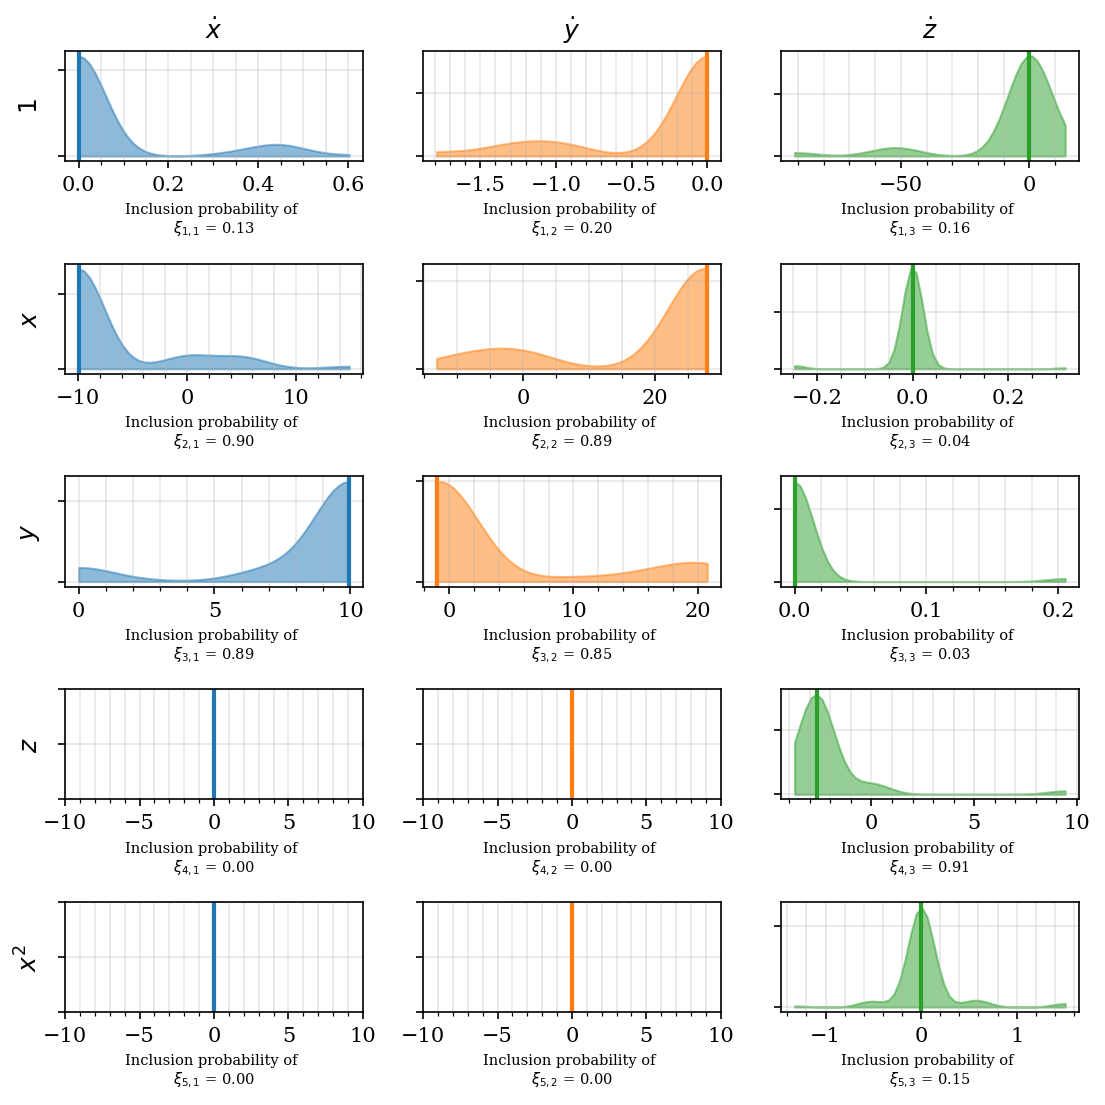

In [9]:
plot_coef_distribution(
    np.stack(xis, axis=-1)[:5],
    state_names, lib_names, useMedian=True
)

Before we move onto the last ensembling post-processing step, let us combine library ensembling with data bootstrapping in a single function. The same implementation structure can be found in `pysindy.optimizers.EnsembleOptimizer`.

In [10]:
ensemble??

Signature:
ensemble(
    theta: numpy.ndarray,
    xdot: numpy.ndarray,
    lam: float = 0.01,
    l2_norm: float = 0.001,
    bootstrap: bool = False,
    library_ensemble: bool = False,
    replace: bool = True,
    n_candidate_to_drop: int | None = None,
    n_models: int = 20,
    n_subset: int | None = None,
) -> numpy.ndarray
Source:   
def ensemble(
        theta: np.ndarray, xdot: np.ndarray,
        lam: float = 0.01, l2_norm: float = 1e-3,
        bootstrap: bool = False, library_ensemble: bool = False,
        replace: bool = True, n_candidate_to_drop: Optional[int] = None,
        n_models: int = 20, n_subset: Optional[int] = None
) -> np.ndarray:
    """
    Function that produces SINDy model ensembles.

    Args:
        theta (np.ndarray): Candidate function library matrix.
        xdot (np.ndarray): Time derivative matrix.
        lam (float, optional): Regularization parameter. Defaults to 0.01.
        l2_norm (float, optional): L2 norm for regularization. Defaults to

## Double Bragging via Inclusion Probability Thresholding

After an initial library ensembling step, we can post-process with an additional ensembling step that removes library terms based on the inclusion probability. The reduction in total library size would improve the conditioning of the sparse regression problem.

In [11]:
# Define inclusion probability threshold
incl_thres: float = 0.6

# Stack the list of models into an array
xis_stacked: np.ndarray = np.stack(xis, axis=-1)

# Get thresholded indices using inclusion probability
threshold_idx: np.ndarray = (np.count_nonzero(
    xis_stacked, axis=-1
) / xis_stacked.shape[-1]) > incl_thres

# Initialise the double bragged model
double_brag_xi: np.ndarray = np.zeros(xis_stacked.shape)

# Carry out second library ensembling just with data bootstrapping for each
# state
for idx in range(xdot.shape[1]):
    double_brag_xi[threshold_idx[:, idx], idx:idx+1, :] = ensemble(
        theta[:, threshold_idx[:, idx]], xdot[:, idx:idx+1],
        lam, l2_norm,
        bootstrap=True, library_ensemble=False,
        n_models=B
    )

# Ensemble the final model by computing the mean and threshold again
xi: np.ndarray = np.median(double_brag_xi, axis=-1)
xi[np.abs(xi) < lam] = 0.0
display(Math(print_latex_eqn(xi, state_names, lib_names)))

<IPython.core.display.Math object>

As we can see in the coefficient distribution below, all library terms with an inclusion probability below the set threshold are now completely sparsified from all ensembled models.

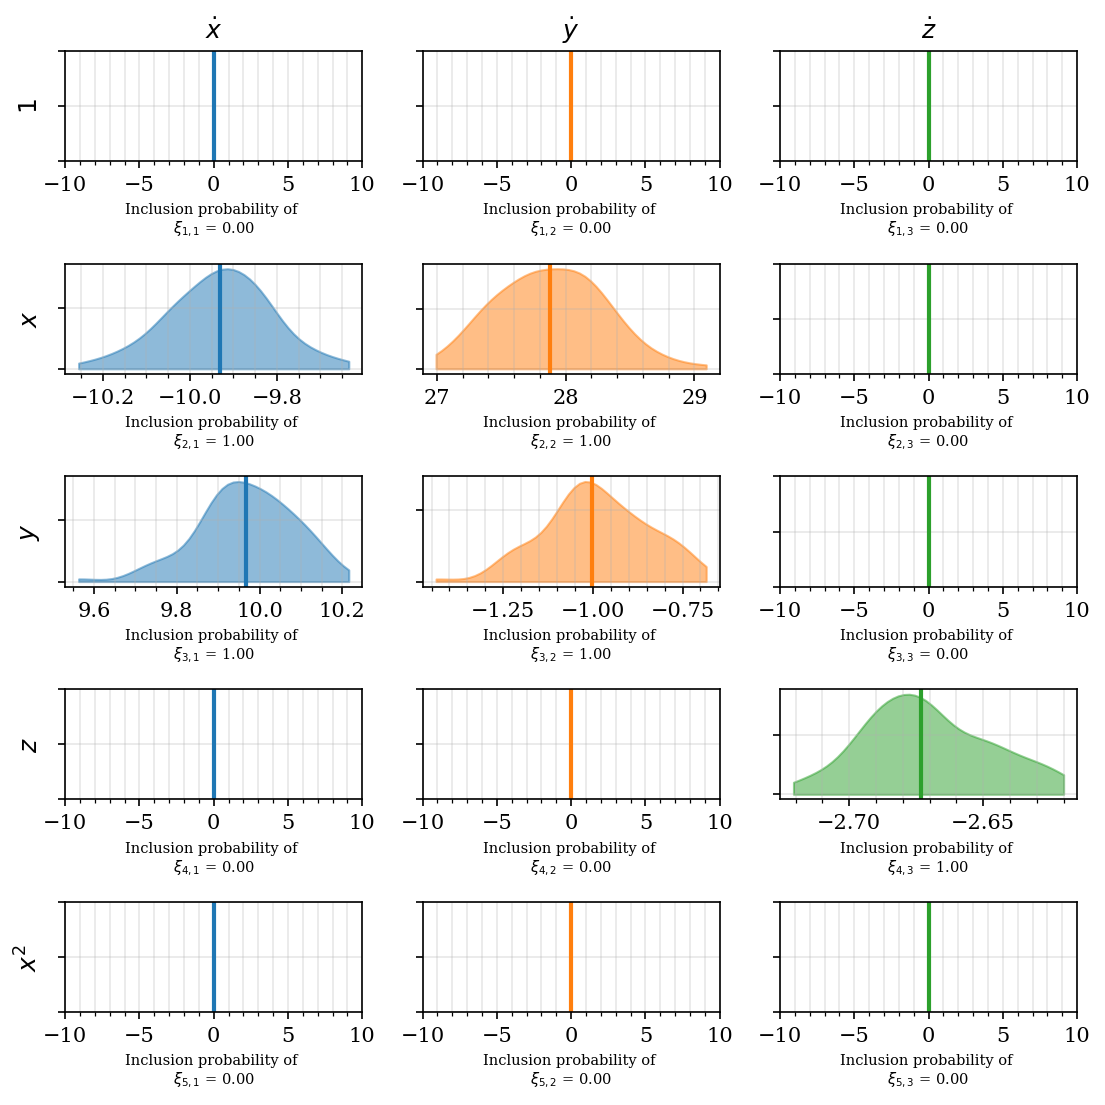

In [12]:
plot_coef_distribution(
    double_brag_xi[:5],
    state_names, lib_names, useMedian=True
)

# Benchmarking

Let us now benchmark:
* SINDy without any ensembling
* SINDy with data bragging (without replacement)
* SINDy with data bragging (without replacement) and library ensembling
* SINDy with double bragging and thresholding via inclusion probability

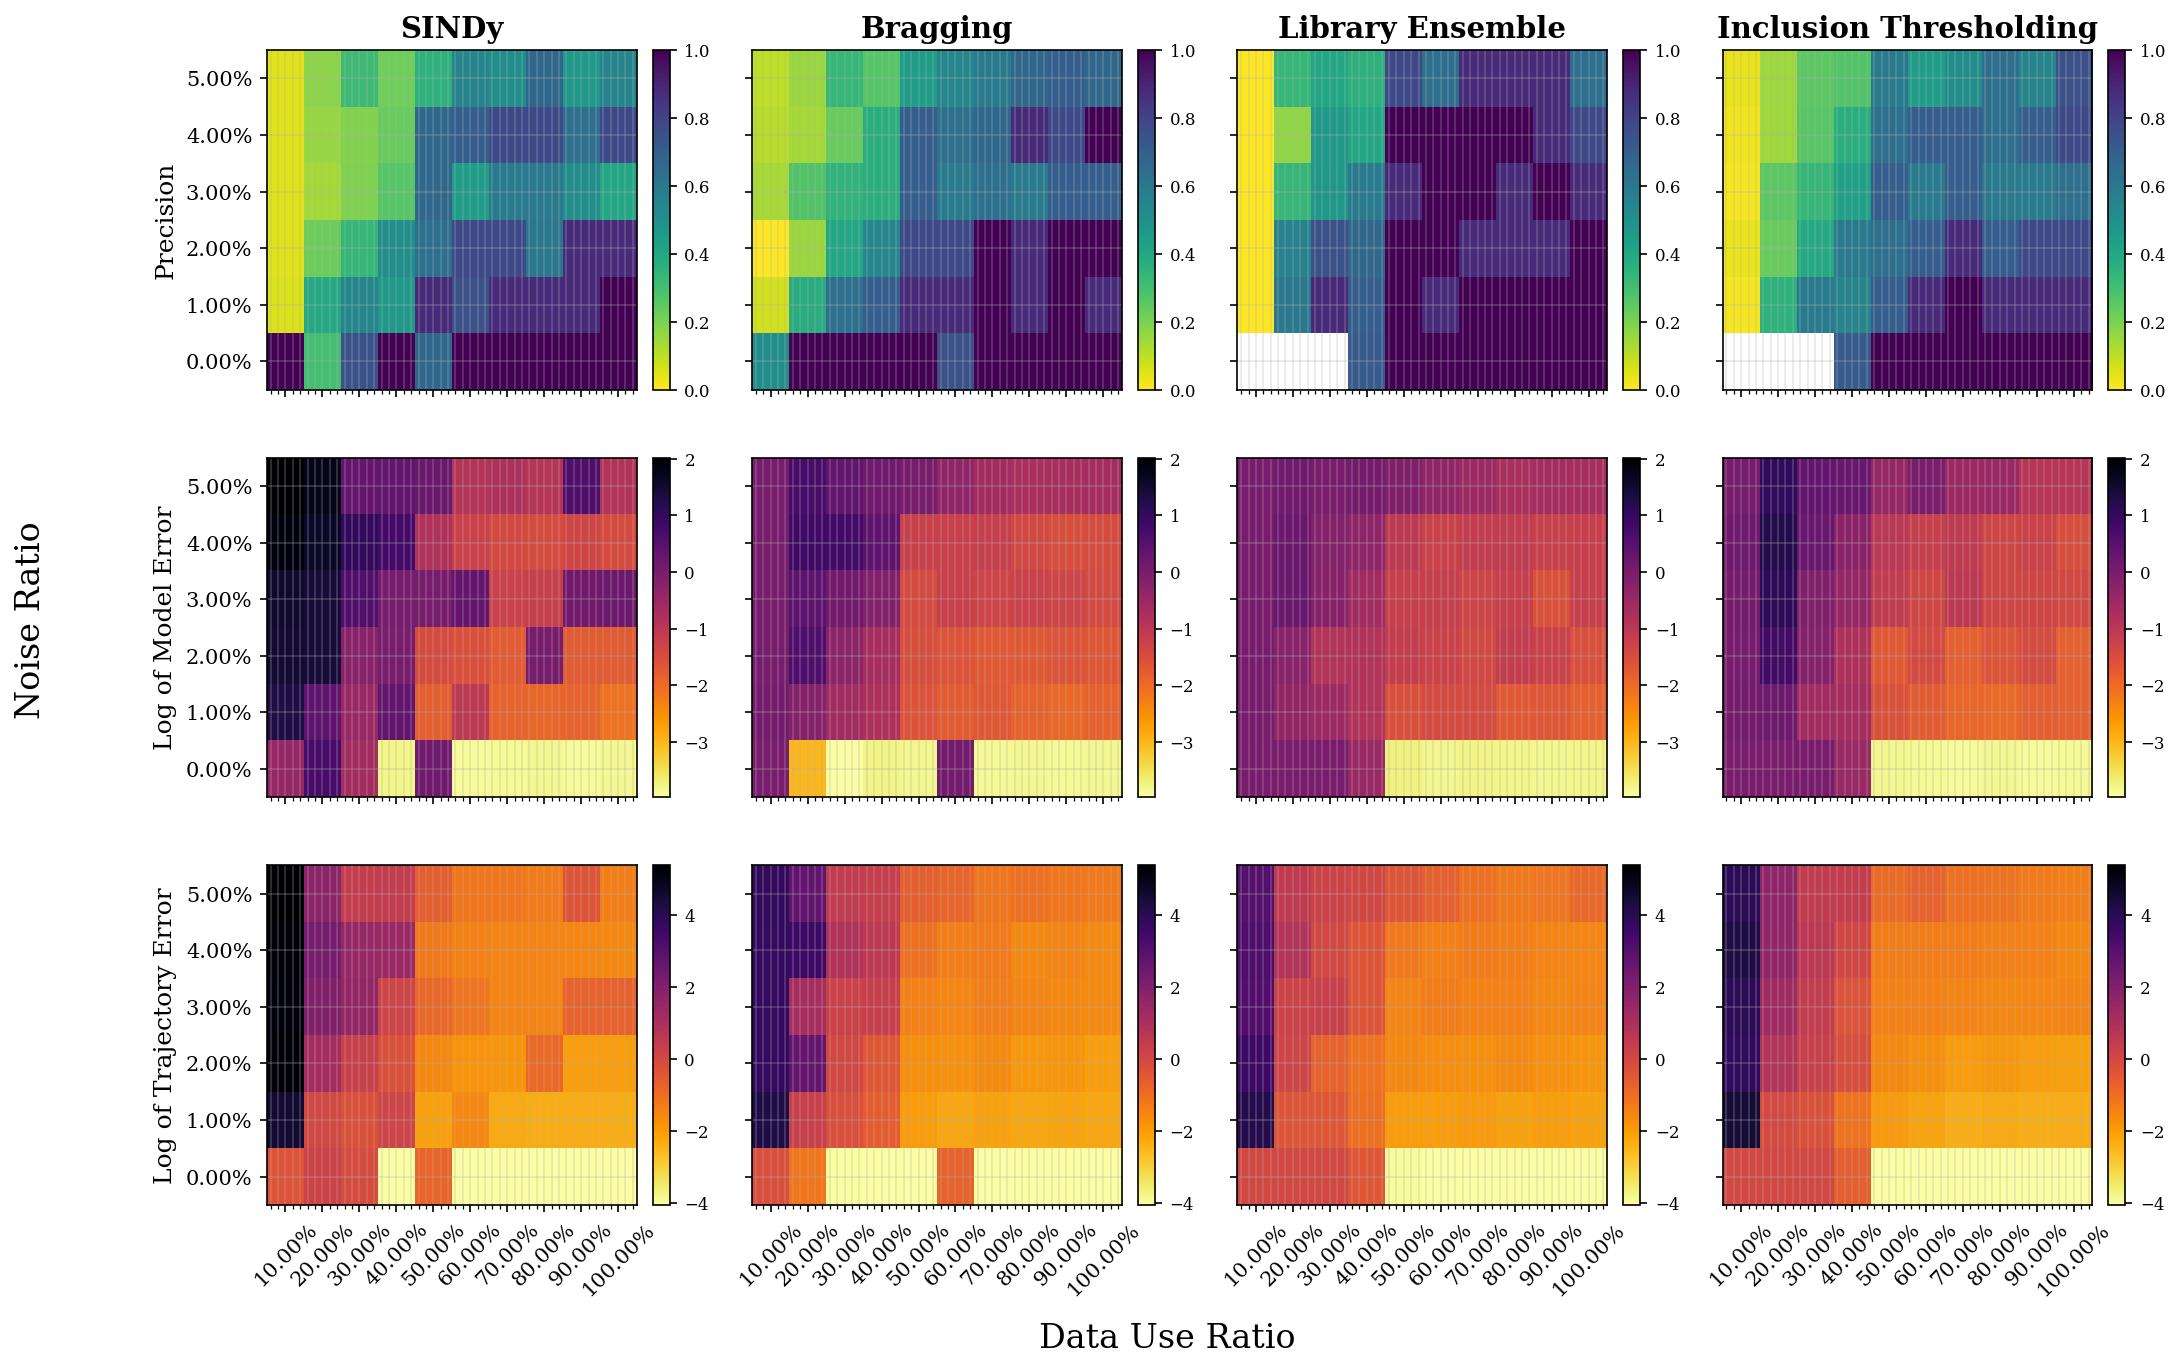

In [13]:
# Define data use ratios for benchmarking and train-validation split
data_use_ratios: np.ndarray = np.linspace(0.1,1,10)
training_validation_split: float = 0.5

# Define SINDy parameters
poly_order: int = 5
include_bias: bool = True
lam: float = 0.2
l2_norm: float = 0.001
incl_threshold: float = 0.4

# True sparse weight matrices with 5th order polynomial library with bias term
# for Lorenz ODE
lorenz_true_xi: np.ndarray = np.zeros((56,3))
lorenz_true_xi[1,0] = -lorenz_params[0]
lorenz_true_xi[2,0] = lorenz_params[0]
lorenz_true_xi[1,1] = lorenz_params[2]
lorenz_true_xi[2,1] = -1.0
lorenz_true_xi[6,1] = -1.0
lorenz_true_xi[3,2] = -lorenz_params[1]
lorenz_true_xi[5,2] = 1.
if not include_bias:
    lorenz_true_xi = lorenz_true_xi[1:]

# Get training data cutoff index
training_cutoff = int(np.round(training_validation_split * t.shape[0]))

# Compute validation data from clean data
validation_xdot = ps.FiniteDifference(4)._differentiate(
    x[training_cutoff:, :], t[training_cutoff:]
)
validation_theta, lib_names = poly_lib(
    x[training_cutoff:, :], poly_order, include_bias, state_names
)

# Initialise noisy library matrices and derivative matrices
noisy_xdots: list[np.ndarray] = list()
noisy_thetas: list[np.ndarray] = list()

# Compute all noisy library matrices and derivative matrices
for noiseIdx in range(len(noise_ratios)):

    # Smoothen training data (`ps.SmoothedFiniteDifference` may also be used)
    x_noisy_smooth = signal.savgol_filter(
        x_noisy[noiseIdx][:training_cutoff, :], 5, 3, axis=0
    )

    noisy_xdots.append(ps.FiniteDifference(4)._differentiate(
        x_noisy_smooth, t[:training_cutoff]
    ))
    noisy_thetas.append(poly_lib(
        x_noisy_smooth, poly_order, include_bias
    )[0])

# Benchmark default SINDy, SINDy with bragging, library ensembling and double
# bragging using inclusion probability thresholding
xis, metrics_data = benchmark_ensemble(
    noise_ratios, data_use_ratios,
    noisy_thetas, noisy_xdots,
    validation_theta, validation_xdot,
    lam, l2_norm, incl_threshold,
    100, int(0.1 * validation_theta.shape[1]),
    lorenz_true_xi[:validation_theta.shape[1], :]
)
plot_heatmap(noise_ratios, data_use_ratios, metrics_data)

# Uncertainty Quantification of Model Prediction

Using the collection of ensembled models, we may quantify the uncertainty of the predicted trajectory by analyzing the distribution of its ensembled predictions. We quantify the uncertainty based off the 95% percentile interval around the mean prediction.

<>:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
/var/folders/j3/qn_kk08j1hqcw5jlph49xzch0000gp/T/ipykernel_29182/1274871265.py:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  t[training_cutoff:], [f'$\dot{{{name}}}$' for name in state_names]


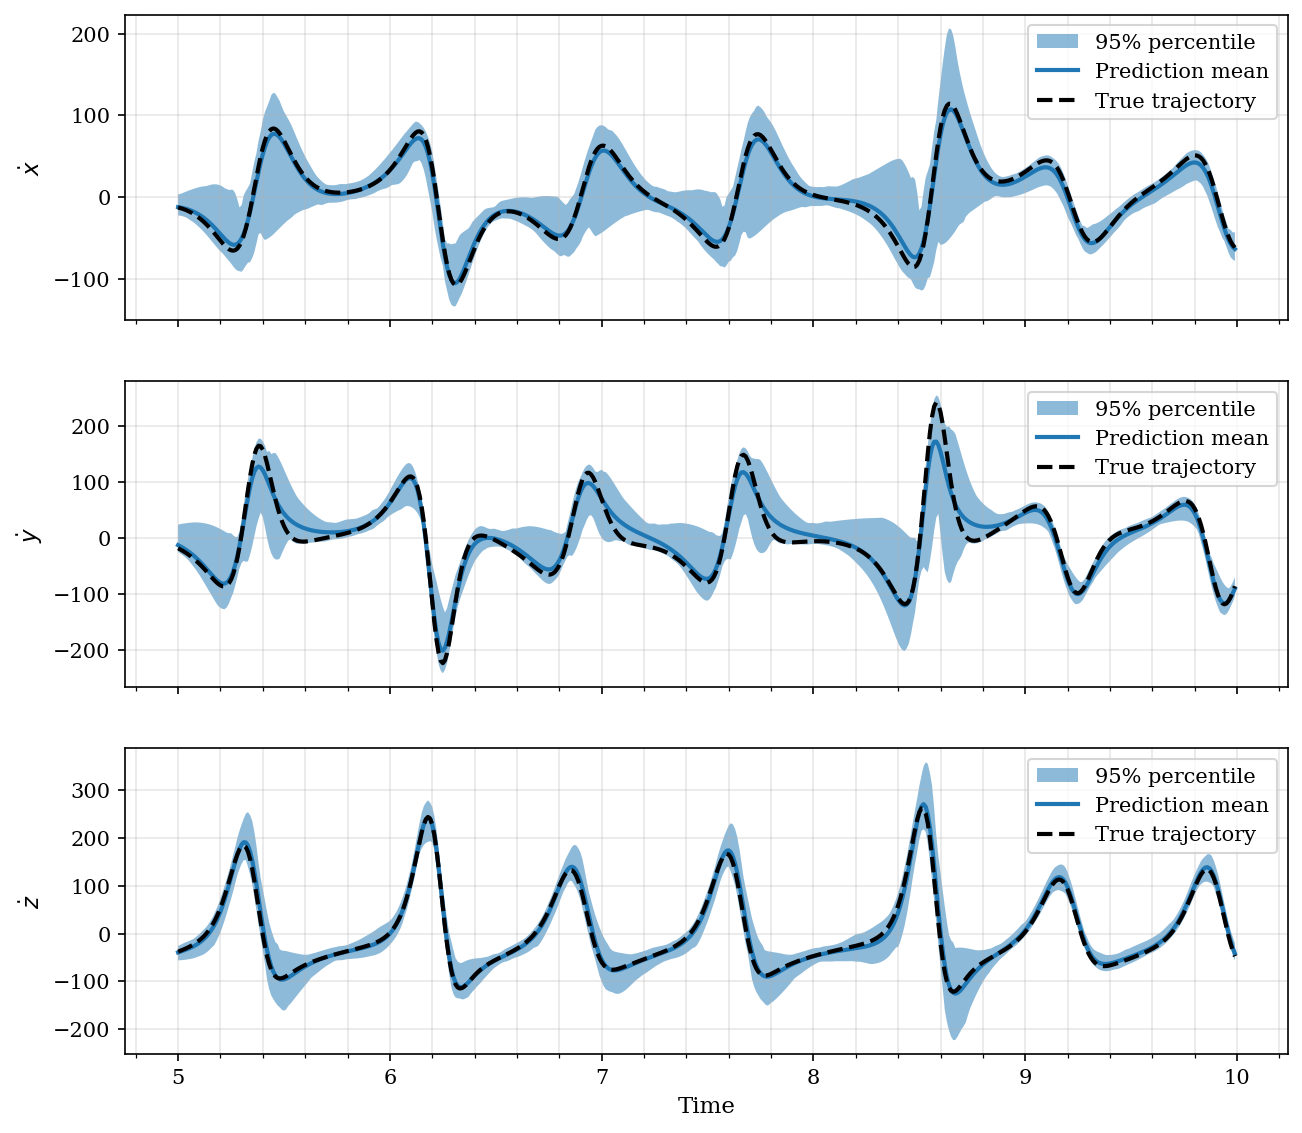

In [14]:
# Define the noise and data use level to visualize the trajectory for
noise_ratio = 0.05
data_use_ratio = 0.5
n_predicts = 100

noise_idx = np.argmin(np.abs(noise_ratios - noise_ratio))
data_use_idx = np.argmin(np.abs(data_use_ratios - data_use_ratio))

plot_predict_trajectory(
    xis['Library Ensemble'][noise_idx, data_use_idx],
    validation_theta, validation_xdot,
    t[training_cutoff:], [f'$\dot{{{name}}}$' for name in state_names]
)